# KV grupitöö andmete analüüsimine ja mudeldamine

### Installime ja impordime vajalikud Pythoni teegid

In [1]:
!pip install pandas sqlalchemy
!pip install pandas
!pip install psycopg2-binary
!pip install statsmodels matplotlib seaborn numpy streamlit plotly 

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -------------------- ------------------- 5.0/9.7 MB 29.1 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 29.4 MB/s  0:00:00


In [2]:
import pandas as pd
from sqlalchemy import create_engine, inspect
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

### Tõmbame PostgreSQL'ist fact ja dim tabelid Pythonisse

In [3]:
# 1. PostgreSQL andmebaasi ühenduse andmed
DB_USER = "postgres"           # PostgreSQL vaikimisi kasutaja on tavaliselt postgres
DB_PASSWORD = "andmed"     
DB_HOST = "localhost"          # Kui andmebaas jookseb sinu arvutis
DB_PORT = "5432"               # PostgreSQL vaikimisi port
DB_NAME = "postgres"

In [4]:
# 2. Loo ühenduse mootor
connection_string = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_string)

In [5]:
# Sõnastik, kuhu kõik tabelid salvestatakse
tabelid = {}

In [6]:

# Määra skeemi nimi, kust andmeid soovid
SIHT_SCHEMA = "grupitoo_kv"

# Määra ära tabelid, mida skeemist soovid

vajalikud_tabelid = ['dim_county', 'fact_kv', 'dim_time', 'fact_palk', 'fact_intressid', 'fact_thi']

# Kood, mis tõmbab kõik tabelid korraga

try:
    with engine.connect() as connection:
        for tabeli_nimi in vajalikud_tabelid:
            query = f'SELECT * FROM "{SIHT_SCHEMA}"."{tabeli_nimi}"'
            
            # Tõmbab mällu ainult valitud tabeli
            tabelid[tabeli_nimi] = pd.read_sql_query(query, connection)
            print(f"✓ Vajalik tabel '{tabeli_nimi}' edukalt tõmmatud! Ridu: {len(tabelid[tabeli_nimi])}")
            
    print("\nValitud tabelid on edukalt mälus ja valmis kasutamiseks!")

except Exception as e:
    print(f"Tekkis viga: {e}. Kontrolli, kas tabelite nimed nimekirjas on kirjutatud õigesti!")

✓ Vajalik tabel 'dim_county' edukalt tõmmatud! Ridu: 15
✓ Vajalik tabel 'fact_kv' edukalt tõmmatud! Ridu: 1289
✓ Vajalik tabel 'dim_time' edukalt tõmmatud! Ridu: 86
✓ Vajalik tabel 'fact_palk' edukalt tõmmatud! Ridu: 1290
✓ Vajalik tabel 'fact_intressid' edukalt tõmmatud! Ridu: 86
✓ Vajalik tabel 'fact_thi' edukalt tõmmatud! Ridu: 86

Valitud tabelid on edukalt mälus ja valmis kasutamiseks!


### Eraldame kõik sissetõmmatud tabelid üksteisest

In [7]:
dim_time = tabelid["dim_time"]
dim_county = tabelid["dim_county"]
fact_kv = tabelid["fact_kv"]
fact_palk = tabelid["fact_palk"]
fact_thi = tabelid["fact_thi"]
fact_intressid = tabelid["fact_intressid"]

### Ühendame (joinime) fact ja dim tabelid

In [8]:
# 1. Alustame peamisest kinnisvara faktitabelist ja lisame sellele dimensioonid
df_koond = pd.merge(
    fact_kv,
    dim_county,
    left_on="fk_county_id",
    right_on="pk_county_id",
    how="left",
)
df_koond = pd.merge(
    df_koond, dim_time, left_on="fk_quarter_id", right_on="pk_quarter_id", how="left"
)

In [9]:
# 2. Lisame palga andmed (ühildame nii asukoha kui ka kvartali järgi)
df_koond = pd.merge(
    df_koond,
    fact_palk,
    on=["fk_county_id", "fk_quarter_id"],
    how="left",
    suffixes=("", "_palk"),
)

In [10]:
# 3. Lisame tarbijahinnaindeksi (THI) andmed (ühildame ainult kvartali järgi)
df_koond = pd.merge(
    df_koond, fact_thi, on="fk_quarter_id", how="left", suffixes=("", "_thi")
)

In [11]:
# 4. Lisame intresside andmed (ühildame ainult kvartali järgi)
df_koond = pd.merge(
    df_koond,
    fact_intressid,
    on="fk_quarter_id",
    how="left",
    suffixes=("", "_intress"),
)

In [12]:
# --- TULEMUSE KONTROLL ---
print(f"Koondtabeli kuju (ridu, veerge): {df_koond.shape}")
print("\nEsimesed 5 rida lõplikust analüüsitabelist:")
display(df_koond.head())

Koondtabeli kuju (ridu, veerge): (1289, 14)



Esimesed 5 rida lõplikust analüüsitabelist:


,fk_quarter_id,transaction_count,avg_price_m2,fk_county_id,pk_county_id,county_name,pk_quarter_id,year_number,quarter_number,quarter_string,half_year,average_salary,keskmine_indeks,intress
0,2005-01-01,2946,758.0,1,1,Harju maakond,2005-01-01,2005,1,2005 I,1,552,135.86,3.42
1,2005-01-01,8,163.0,2,2,Hiiu maakond,2005-01-01,2005,1,2005 I,1,400,135.86,3.42
2,2005-01-01,406,117.0,3,3,Ida-Viru maakond,2005-01-01,2005,1,2005 I,1,356,135.86,3.42
3,2005-01-01,52,132.0,5,5,Järva maakond,2005-01-01,2005,1,2005 I,1,390,135.86,3.42
4,2005-01-01,59,84.0,4,4,Jõgeva maakond,2005-01-01,2005,1,2005 I,1,394,135.86,3.42


##### Tabeli puhastamine (üleliigsete veergude eemaldamine)

In [13]:
# 1. Koosta nimekiri veergudest, mida sul analüüsiks ja graafikuteks vaja EI OLE
veerud_eemaldamiseks = [
    "pk_county_id",
    "pk_quarter_id",
    "quarter_string",
    "half_year"
]

In [14]:
# 2. Eemalda veerud (errors='ignore' hoiab ära veateate, kui mõnda veergu nimekirjas pole)
df_puhas = df_koond.drop(columns=veerud_eemaldamiseks, errors='ignore')

# 3. Kontrolli tulemust
print(f"Enne oli veere: {df_koond.shape[1]} | Nüüd on veere: {df_puhas.shape[1]}")
print("\nPuhastatud tabeli veerud:")
print(list(df_puhas.columns))

Enne oli veere: 14 | Nüüd on veere: 10

Puhastatud tabeli veerud:
['fk_quarter_id', 'transaction_count', 'avg_price_m2', 'fk_county_id', 'county_name', 'year_number', 'quarter_number', 'average_salary', 'keskmine_indeks', 'intress']


In [15]:
# Muudame veerunimed ilusamaks
df_puhas = df_puhas.rename(columns={
    "transaction_count": "kinnisvara_tehingute_arv",
    "avg_price_m2": "keskmine_ruutmeetri_hind",
    "county_name": "maakond",
    "year_number": "aasta",
    "quarter_number": "kvartal",
    "average_salary": "keskmine_brutopalk",
    "keskmine_indeks": "tarbijahinnaindeks",
    "intress": "kodulaenu_intressimäär"
})

# Kuva esimesed read uuest puhtast tabelist
display(df_puhas.head())

,fk_quarter_id,kinnisvara_tehingute_arv,keskmine_ruutmeetri_hind,fk_county_id,maakond,aasta,kvartal,keskmine_brutopalk,tarbijahinnaindeks,kodulaenu_intressimäär
0,2005-01-01,2946,758.0,1,Harju maakond,2005,1,552,135.86,3.42
1,2005-01-01,8,163.0,2,Hiiu maakond,2005,1,400,135.86,3.42
2,2005-01-01,406,117.0,3,Ida-Viru maakond,2005,1,356,135.86,3.42
3,2005-01-01,52,132.0,5,Järva maakond,2005,1,390,135.86,3.42
4,2005-01-01,59,84.0,4,Jõgeva maakond,2005,1,394,135.86,3.42


##### Tabeli puhastamine (tühjade väärtuste kontrollimine)

In [16]:
# Kuvab tühjade väärtuste summa iga veeru kohta
tyhjad_arvud = df_puhas.isnull().sum()
tyhjad_protsent = (df_puhas.isnull().sum() / len(df_puhas)) * 100

# Loome ülevaatliku tabeli
tyhjade_ylevaade = pd.DataFrame({'Tühje väärtusi': tyhjad_arvud, 'Protsent (%)': tyhjad_protsent})
display(tyhjade_ylevaade[tyhjade_ylevaade['Tühje väärtusi'] > 0])

,Tühje väärtusi,Protsent (%)
keskmine_ruutmeetri_hind,2,0.155159


In [17]:
# .any(axis=1) otsib tühje väärtusi horisontaalselt üle kõigi veergude
df_tyhjad_read = df_puhas[df_puhas.isnull().any(axis=1)]

print(f"Kokku leiti {len(df_tyhjad_read)} rida, kus on tühje väärtusi.")
# Kuvab need read interaktiivse tabelina
display(df_tyhjad_read)

Kokku leiti 2 rida, kus on tühje väärtusi.


,fk_quarter_id,kinnisvara_tehingute_arv,keskmine_ruutmeetri_hind,fk_county_id,maakond,aasta,kvartal,keskmine_brutopalk,tarbijahinnaindeks,kodulaenu_intressimäär
300,2010-01-01,3,NaN,2,Hiiu maakond,2010,1,610,171.35,3.59
540,2014-01-01,3,NaN,2,Hiiu maakond,2014,1,803,196.30,2.55


In [18]:
# 1. Eemaldame ainult need read, kus korrelatsiooni jaoks kriitilised andmed on puudu, kasutades tabeli täpseid veerunimesi
df_analuys = df_puhas.dropna(subset=['keskmine_ruutmeetri_hind', 'keskmine_brutopalk', 'tarbijahinnaindeks'])

print(f"Algne ridade arv: {len(df_puhas)}")
print(f"Puhastatud ridade arv (mida kasutame analüüsis): {len(df_analuys)}")
print(f"Eemaldati kokku {len(df_puhas) - len(df_analuys)} rida, kus andmed olid puudulikud.")

# 2. Kontrolliks veendume, et uues tabelis on tühjade ridade arv null
print(f"Tühje ridu järele jäänud tabelis: {df_analuys.isnull().any(axis=1).sum()}")

print("-" * 50)

Algne ridade arv: 1289
Puhastatud ridade arv (mida kasutame analüüsis): 1287
Eemaldati kokku 2 rida, kus andmed olid puudulikud.
Tühje ridu järele jäänud tabelis: 0
--------------------------------------------------


In [19]:
# 3. Arvutame kohe puhta tabeli põhjal palga ja ruutmeetri hinna korrelatsiooni
korrelatsioon = df_analuys['keskmine_brutopalk'].corr(df_analuys['keskmine_ruutmeetri_hind'])
print(f"Keskmise brutopalga ja ruutmeetri hinna vaheline korrelatsioon on: {korrelatsioon:.2f}")

Keskmise brutopalga ja ruutmeetri hinna vaheline korrelatsioon on: 0.64


# OLS analüüs 1 kvartali nihkega - Eesti kokku

### Nihkega (lag) tunnuste loomine

In [20]:
# Sorteerime andmed ajaliselt, et nihe arvutataks õiges järjekorras
df_mudel = df_analuys.sort_values(by=['maakond', 'fk_quarter_id']).copy()

# Määra, mitme kvartali pikkust nihet (lag) soovid testida (nt 2 kvartalit = pool aastat)
NIHE = 1

In [21]:
# Loome nihkega tunnused IGAS MAAKONNAS ERALDI (groupby)
df_mudel['palk_lag'] = df_mudel.groupby('maakond')['keskmine_brutopalk'].shift(NIHE)
df_mudel['thi_lag'] = df_mudel.groupby('maakond')['tarbijahinnaindeks'].shift(NIHE)
df_mudel['intress_lag'] = df_mudel.groupby('maakond')['kodulaenu_intressimäär'].shift(NIHE)

# Kuna nihke tõttu tekivad esimeste kvartalite kohta tühjad read (NaN), eemaldame need
df_mudel_puhas = df_mudel.dropna(subset=['palk_lag', 'thi_lag', 'intress_lag', 'keskmine_ruutmeetri_hind'])


#### Regressioonanalüüs

In [22]:
# Sõltumatud tunnused (X) - X-i külge tuleb lisada konstant (vabaliige)
X = df_mudel_puhas[['palk_lag', 'thi_lag', 'intress_lag']]
X = sm.add_constant(X)

# Sõltuv tunnus (Y) - see, mida prognoosime
Y = df_mudel_puhas['keskmine_ruutmeetri_hind']

# Loome ja sobitame OLS (Ordinary Least Squares) mudeli
mudel = sm.OLS(Y, X).fit()

# Kuvame tulemuste põhjaliku koondraporti
print(mudel.summary())

                               OLS Regression Results                               
Dep. Variable:     keskmine_ruutmeetri_hind   R-squared:                       0.608
Model:                                  OLS   Adj. R-squared:                  0.607
Method:                       Least Squares   F-statistic:                     656.3
Date:                      Mon, 05 Oct 2026   Prob (F-statistic):          2.02e-257
Time:                              15:02:22   Log-Likelihood:                -9164.5
No. Observations:                      1272   AIC:                         1.834e+04
Df Residuals:                          1268   BIC:                         1.836e+04
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

##### R-squared: Näitab vahemikus 0 kuni 1, kui suure protsendi kinnisvarahinna muutusest suudavad sinu valitud kolm nihkega näitajat ära seletada. (Nt 0.75 tähendab, et mudel seletab 75% hindade kõikumisest). 
##### P>|t| (p-väärtus iga näitaja taga): Kui see number on väiksem kui 0.05, siis on selle näitaja mõju kinnisvarahinnale statistiliselt oluline. Kui see on suurem (nt 0.42), siis sellel näitajal antud nihke puhul usaldusväärset mõju pole. 
##### coef (koefitsient): Näitab mõju suunda ja tugevust. Näiteks intress_lag negatiivne koefitsient tähendab, et intressimäärade tõus pool aastat tagasi toob täna kaasa kinnisvarahinna languse. 

# OLS maakondade lõikes, kus automaatselt leiame sobiva time lag'i (1 kuni 8 kvartalit lag)

In [23]:
# 1. Ettevalmistus: loome maakondade dummyd (fikseeritud mõjud)
# Drop_first=True hoiab ära multikollineaarsuse (dummy variable trap)
df_dummies = pd.get_dummies(df_analuys, columns=['maakond'], drop_first=True, dtype=int)

# Salvestame tulemused siia, et pärast võrrelda
nihke_tulemused = []
# Testime nihkeid 1 kuni 4 kvartalit
for nihe in [1, 2, 3, 4, 5, 6, 7, 8] :
    df_temp = df_dummies.sort_values(by=['fk_county_id', 'fk_quarter_id']).copy()
    
    # Loome nihked iga maakonna (fk_county_id) lõikes eraldi
    df_temp['palk_lag'] = df_temp.groupby('fk_county_id')['keskmine_brutopalk'].shift(nihe)
    df_temp['thi_lag'] = df_temp.groupby('fk_county_id')['tarbijahinnaindeks'].shift(nihe)
    df_temp['intress_lag'] = df_temp.groupby('fk_county_id')['kodulaenu_intressimäär'].shift(nihe)
    
    # Eemaldame nihkest tingitud tühjad read
    kriitilised = ['palk_lag', 'thi_lag', 'intress_lag', 'keskmine_ruutmeetri_hind']
    df_temp_puhas = df_temp.dropna(subset=kriitilised)
    
    # Dünaamiliselt leiame kõik maakondade dummyd, mis andmetesse tekkisid
    maakonna_veerud = [col for col in df_temp_puhas.columns if col.startswith('maakond_')]
    
    # Sõltumatud muutujad (X): nihkega majandusnäitajad + maakondade eripärad
    tunnused = ['palk_lag', 'thi_lag', 'intress_lag'] + maakonna_veerud
    X = df_temp_puhas[tunnused]
    X = sm.add_constant(X)
    
    # Sõltuv muutuja (Y): ruutmeetri hind
    Y = df_temp_puhas['keskmine_ruutmeetri_hind']
    
    # Mudeli sobitamine
    mudel = sm.OLS(Y, X).fit()
    
    # Salvestame R2 ja mudeli objekti edasiseks kasutamiseks
    nihke_tulemused.append({
        'Nihe (kvartalit)': nihe,
        'R-squared': mudel.rsquared,
        'Mudel': mudel,
        'Andmed': df_temp_puhas
    })
    print(f"Nihe {nihe} kvartalit tested -> Mudeli R-squared: {mudel.rsquared:.4f}")

Nihe 1 kvartalit tested -> Mudeli R-squared: 0.8678
Nihe 2 kvartalit tested -> Mudeli R-squared: 0.8605
Nihe 3 kvartalit tested -> Mudeli R-squared: 0.8515
Nihe 4 kvartalit tested -> Mudeli R-squared: 0.8456
Nihe 5 kvartalit tested -> Mudeli R-squared: 0.8387
Nihe 6 kvartalit tested -> Mudeli R-squared: 0.8370
Nihe 7 kvartalit tested -> Mudeli R-squared: 0.8345
Nihe 8 kvartalit tested -> Mudeli R-squared: 0.8363


In [24]:
# 2. Leiame parima nihke
parim_tulemus = max(nihke_tulemused, key=lambda x: x['R-squared'])
parim_nihe = parim_tulemus['Nihe (kvartalit)']
print(f"\n🏆 Parim mudel on {parim_nihe}-kvartalise nihkega (R² = {parim_tulemus['R-squared']:.4f})")


🏆 Parim mudel on 1-kvartalise nihkega (R² = 0.8678)


#### Parima mudeli visualiseerimine

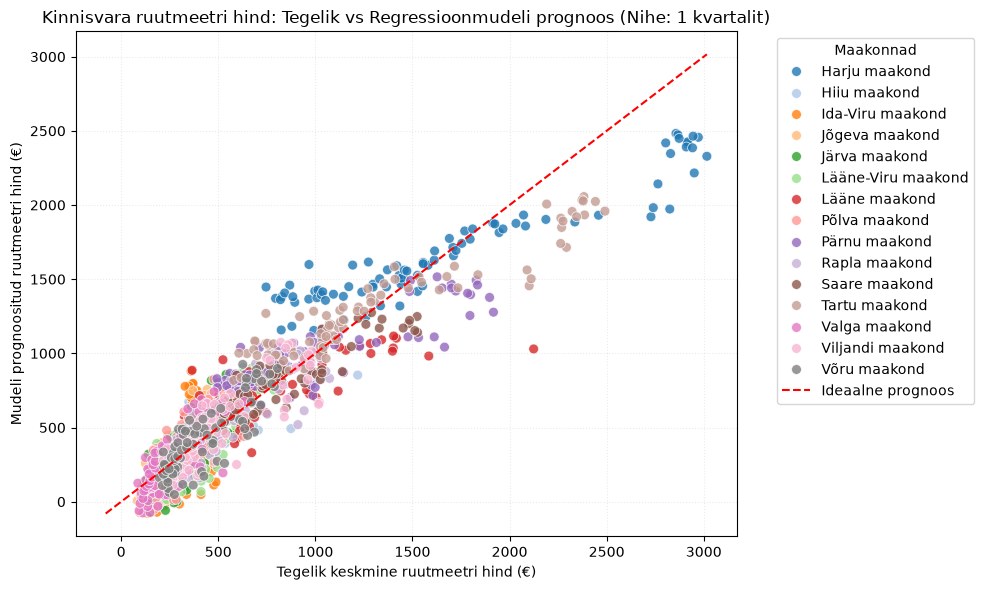


--- PARIMA MUDELI DETAILNE RAPORT ---
                               OLS Regression Results                               
Dep. Variable:     keskmine_ruutmeetri_hind   R-squared:                       0.868
Model:                                  OLS   Adj. R-squared:                  0.866
Method:                       Least Squares   F-statistic:                     484.4
Date:                      Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                              15:02:23   Log-Likelihood:                -8473.5
No. Observations:                      1272   AIC:                         1.698e+04
Df Residuals:                          1254   BIC:                         1.708e+04
Df Model:                                17                                         
Covariance Type:                  nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------

In [25]:
# 3. Visualiseerimine: Tegelik vs Prognoositud hind parima nihke korral
df_parim = parim_tulemus['Andmed'].copy()
parim_mudel = parim_tulemus['Mudel']

# Toome algsest 'df_analuys' tabelist tekstilised maakondade nimed indeksi alusel tagasi
df_parim['maakond'] = df_analuys.loc[df_parim.index, 'maakond']

# Arvutame mudeli prognoosid
X_tunnused = sm.add_constant(df_parim[parim_mudel.model.exog_names[1:]])
df_parim['prognoositud_hind'] = parim_mudel.predict(X_tunnused)

# Joonistame graafiku
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_parim, 
    x='keskmine_ruutmeetri_hind', 
    y='prognoositud_hind', 
    hue='maakond', 
    palette='tab20', 
    alpha=0.8, 
    edgecolor='w', 
    s=50
)
# Lisame ideaalse prognoosi joone (kus prognoos = tegelik)
max_val = max(df_parim['keskmine_ruutmeetri_hind'].max(), df_parim['prognoositud_hind'].max())
min_val = min(df_parim['keskmine_ruutmeetri_hind'].min(), df_parim['prognoositud_hind'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideaalne prognoos')

# Pealkirjad ja paigutus
plt.title(f'Kinnisvara ruutmeetri hind: Tegelik vs Regressioonmudeli prognoos (Nihe: {parim_nihe} kvartalit)', fontsize=12)
plt.xlabel('Tegelik keskmine ruutmeetri hind (€)', fontsize=10)
plt.ylabel('Mudeli prognoositud ruutmeetri hind (€)', fontsize=10)

# Paigutame legendi graafikust paremale poole
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Maakonnad', frameon=True)

plt.grid(True, alpha=0.25, linestyle=':')
plt.tight_layout()
plt.show()

# Kuvame parima mudeli detailse raporti (p-väärtused ja koefitsiendid)
print("\n--- PARIMA MUDELI DETAILNE RAPORT ---")
print(parim_mudel.summary())

 ##### Majandusnäitajate mõju (1-kvartalise nihkega)
 ##### palk_lag (koefitsient +0.9456): See näitab väga loogilist seost. Kui keskmine brutopalk tõusis eelnevas kvartalis 1 euro võrra, tõusis kinnisvara ruutmeetri hind järgmises kvartalis keskmiselt 0.95 eurot. Palk on turu peamine ja kõige stabiilsem vedur.
 ##### thi_lag (koefitsient -2.6641): Tarbijahinnaindeksil on negatiivne mõju. Kui elukallidus (THI) tõuseb, siis inimeste ostujõud väheneb, sest muudeks kuludeks kulub rohkem raha. Mudel näitab, et THI tõus ühe ühiku võrra tõi kaasa ruutmeetri hinna languse ca 2.66 eurot.
 ##### intress_lag (koefitsient +72.8136) – Üllatustulemus!: Majandusteooria järgi peaks intresside tõus (Euribor) kinnisvarahindu jahutama (mõju peaks olema negatiivne). Mudel näitab aga tugevat positiivset koefitsienti (+72.81). 
 ##### Miks see nii on? See on reaalsete andmete puhul väga tüüpiline nähtus, mida nimetatakse kausaalsuse suunaks või ajatrendiks. Viimasel paaril aastal tõusid Euroopa Keskpanga intressid  (Euribor) väga kiiresti just vastureaktsioonina ülikõrgele inflatsioonile ja kuumale majandusele, mil ka kinnisvarahinnad olid juba tipus. Mudel näeb andmetes, et "kõrge intress = kõrge hind", sest mõlemad liikusid ajas koos üles, mitte andmebaasi eripärast tulenevalt.

##### Maakondade fikseeritud mõjud (Fixed Effects)
##### Kõikide maakondade koefitsiendid on negatiivsed (nt maakond_Ida-Viru maakond on -1020.28). Mida see tähendab? Kuna mudelist jäeti multikollineaarsuse vältimiseks üks maakond baastasemeks (Harjumaa), siis need miinusmärgid näitavad, kui palju odavam on ruutmeetri baashind nendes maakondades võrreldes Harjumaaga, kui majandusnäitajad on võrdsed. Näiteks Ida-Virumaal on ruutmeetri baashind puhtalt geograafilise asukoha tõttu keskmiselt 1020 eurot odavam kui Harjumaal.

### Uus analüüs, kus võtame iga näitaja puhul trendi (taseme) asemel muutuse kvartalis (st KV hinna muutus kvartalis, mitte tase ühel ja teisel kvartalil)

In [26]:
# Sorteerime andmed ajaliselt maakondade kaupa, et muutuste arvutamine oleks korrektne
df_trend = df_analuys.sort_values(by=['maakond', 'fk_quarter_id']).copy()

# --- 1. SAMM: ANDMETE DETRENDIMINE (Kvartalitevahelised muutused) ---
# Arvutame muutused iga maakonna sees eraldi, et vältida maakondade omavahelist segunemist
df_trend['hind_diff'] = df_trend.groupby('maakond')['keskmine_ruutmeetri_hind'].diff()
df_trend['palk_diff'] = df_trend.groupby('maakond')['keskmine_brutopalk'].diff()
df_trend['thi_diff'] = df_trend.groupby('maakond')['tarbijahinnaindeks'].diff()
df_trend['intress_diff'] = df_trend.groupby('maakond')['kodulaenu_intressimäär'].diff()

# --- 2. SAMM: DUMMIES GENEREERIMINE (Kõik maakonnad alles, drop_first=False) ---
df_dummies_all = pd.get_dummies(df_trend, columns=['maakond'], drop_first=True, dtype=int)

nihke_tulemused_diff = []

# Testime uuesti nihkeid 1 kuni 4 kvartalit detrenditud andmetel
for nihe in [1, 2, 3, 4, 5, 6, 7, 8]:
    df_temp = df_dummies_all.copy()
    
    # Loome nihked muutuste (diff) tunnustele maakondade kaupa
    df_temp['palk_lag_diff'] = df_temp.groupby('fk_county_id')['palk_diff'].shift(nihe)
    df_temp['thi_lag_diff'] = df_temp.groupby('fk_county_id')['thi_diff'].shift(nihe)
    df_temp['intress_lag_diff'] = df_temp.groupby('fk_county_id')['intress_diff'].shift(nihe)
    
    # Eemaldame nihkest ja diff-ist tingitud tühjad read
    kriitilised_diff = ['palk_lag_diff', 'thi_lag_diff', 'intress_lag_diff', 'hind_diff']
    df_temp_puhas = df_temp.dropna(subset=kriitilised_diff)
    
    # Leiame kõik maakondade veerud
    maakonna_veerud = [col for col in df_temp_puhas.columns if col.startswith('maakond_')]
    
    # Sõltumatud muutujad (X): EI lisa konstanti (sm.add_constant), sest meil on KÕIK maakonnad alles
    tunnused = ['palk_lag_diff', 'thi_lag_diff', 'intress_lag_diff'] + maakonna_veerud
    X = df_temp_puhas[tunnused]
    
    # Sõltuv muutuja (Y): Hinna muutus
    Y = df_temp_puhas['hind_diff']
    
    # OLS mudel
    mudel = sm.OLS(Y, X).fit()
    
    nihke_tulemused_diff.append({
        'Nihe (kvartalit)': nihe,
        'R-squared': mudel.rsquared,
        'Mudel': mudel,
        'Andmed': df_temp_puhas
    })
    print(f"Detrenditud mudel: Nihe {nihe} kvartal -> R-squared: {mudel.rsquared:.4f}")

# Valime parima nihke detrenditud andmete jaoks
parim_tulemus_diff = max(nihke_tulemused_diff, key=lambda x: x['R-squared'])
parim_nihe_diff = parim_tulemus_diff['Nihe (kvartalit)']
print(f"\n🏆 Detrenditud mudeli parim nihe on: {parim_nihe_diff} kvartal(it)")

# Kuvame uue parima mudeli raporti
print("\n--- DETRENDITUD PARIMA MUDELI DETAILNE RAPORT ---")
print(parim_tulemus_diff['Mudel'].summary())

Detrenditud mudel: Nihe 1 kvartal -> R-squared: 0.0212
Detrenditud mudel: Nihe 2 kvartal -> R-squared: 0.0176
Detrenditud mudel: Nihe 3 kvartal -> R-squared: 0.0149
Detrenditud mudel: Nihe 4 kvartal -> R-squared: 0.0148
Detrenditud mudel: Nihe 5 kvartal -> R-squared: 0.0161
Detrenditud mudel: Nihe 6 kvartal -> R-squared: 0.0154
Detrenditud mudel: Nihe 7 kvartal -> R-squared: 0.0133
Detrenditud mudel: Nihe 8 kvartal -> R-squared: 0.0154

🏆 Detrenditud mudeli parim nihe on: 1 kvartal(it)

--- DETRENDITUD PARIMA MUDELI DETAILNE RAPORT ---
                                 OLS Regression Results                                
Dep. Variable:              hind_diff   R-squared (uncentered):                   0.021
Model:                            OLS   Adj. R-squared (uncentered):              0.008
Method:                 Least Squares   F-statistic:                              1.583
Date:                Mon, 05 Oct 2026   Prob (F-statistic):                      0.0613
Time:             

##### Mudeli tulemus kehv - mudel ja enamus muutujaid statistiliselt ebaolulised

### Uus mudel, kuhu lisame ajatrendi, et intressi ja KV hinna ajatrendi eraldada.

In [27]:
# 1. Sorteerime andmed ajaliselt
df_loplis = df_analuys.sort_values(by=['maakond', 'fk_quarter_id']).copy()

# 2. Loome AJATRENDI tunnuse (järjekorranumber igale kvartalile)
# See imeb endasse üldise pikaajalise inflatsiooni, et näha intressi puhast mõju
kvartali_järjestus = sorted(df_loplis['fk_quarter_id'].unique())
kvartali_mapping = {kvartal: i for i, kvartal in enumerate(kvartali_järjestus)}
df_loplis['aja_trend'] = df_loplis['fk_quarter_id'].map(kvartali_mapping)

# 3. Loome dummies KÕIKIDELE maakondadele (drop_first=False)
df_dummies_all = pd.get_dummies(df_loplis, columns=['maakond'], drop_first=True, dtype=int)

nihke_tulemused_loplis = []

# Testime nihkeid 1 kuni 8 kvartalit
for nihe in range(1, 9):
    df_temp = df_dummies_all.copy()
    
    # Nihked algsetele pikaajalistele näitajatele (mitte diff)
    df_temp['palk_lag'] = df_temp.groupby('fk_county_id')['keskmine_brutopalk'].shift(nihe)
    df_temp['thi_lag'] = df_temp.groupby('fk_county_id')['tarbijahinnaindeks'].shift(nihe)
    df_temp['intress_lag'] = df_temp.groupby('fk_county_id')['kodulaenu_intressimäär'].shift(nihe)
    
    # Sõltuvaks muutujaks on jälle ALGSNE hind, mitte muutus (diff)
    df_temp_puhas = df_temp.dropna(subset=['palk_lag', 'thi_lag', 'intress_lag', 'keskmine_ruutmeetri_hind'])
    
    maakonna_veerud = [col for col in df_temp_puhas.columns if col.startswith('maakond_')]
    
    # Sõltumatud muutujad (ilma const-ita, sest drop_first=False)
    tunnused = ['palk_lag', 'thi_lag', 'intress_lag', 'aja_trend'] + maakonna_veerud
    X = df_temp_puhas[tunnused]
    
    # Sõltuv muutuja (Y): ruutmeetri hind absoluutväärtusena
    Y = df_temp_puhas['keskmine_ruutmeetri_hind']
    
    mudel = sm.OLS(Y, X).fit()
    nihke_tulemused_loplis.append({
        'Nihe (kvartalit)': nihe,
        'R-squared': mudel.rsquared,
        'Mudel': mudel
    })
    print(f"Trendiga mudel: Nihe {nihe} kvartal -> R-squared: {mudel.rsquared:.4f}")

# Valime parima mudeli
parim_loplis = max(nihke_tulemused_loplis, key=lambda x: x['R-squared'])
print(f"\n🏆 Lõpliku trendimudeli parim nihe on: {parim_loplis['Nihe (kvartalit)']} kvartal")

print("\n--- LÕPLIKU JA PUHASTATUD TRENDIMUDELI DETAILNE RAPORT ---")
print(parim_loplis['Mudel'].summary())

Trendiga mudel: Nihe 1 kvartal -> R-squared: 0.9448
Trendiga mudel: Nihe 2 kvartal -> R-squared: 0.9409
Trendiga mudel: Nihe 3 kvartal -> R-squared: 0.9369
Trendiga mudel: Nihe 4 kvartal -> R-squared: 0.9345
Trendiga mudel: Nihe 5 kvartal -> R-squared: 0.9322
Trendiga mudel: Nihe 6 kvartal -> R-squared: 0.9309
Trendiga mudel: Nihe 7 kvartal -> R-squared: 0.9296
Trendiga mudel: Nihe 8 kvartal -> R-squared: 0.9302

🏆 Lõpliku trendimudeli parim nihe on: 1 kvartal

--- LÕPLIKU JA PUHASTATUD TRENDIMUDELI DETAILNE RAPORT ---
                                    OLS Regression Results                                   
Dep. Variable:     keskmine_ruutmeetri_hind   R-squared (uncentered):                   0.945
Model:                                  OLS   Adj. R-squared (uncentered):              0.944
Method:                       Least Squares   F-statistic:                              1192.
Date:                      Mon, 05 Oct 2026   Prob (F-statistic):                        0.00
Time:

##### Loome saadud mudelile joonise

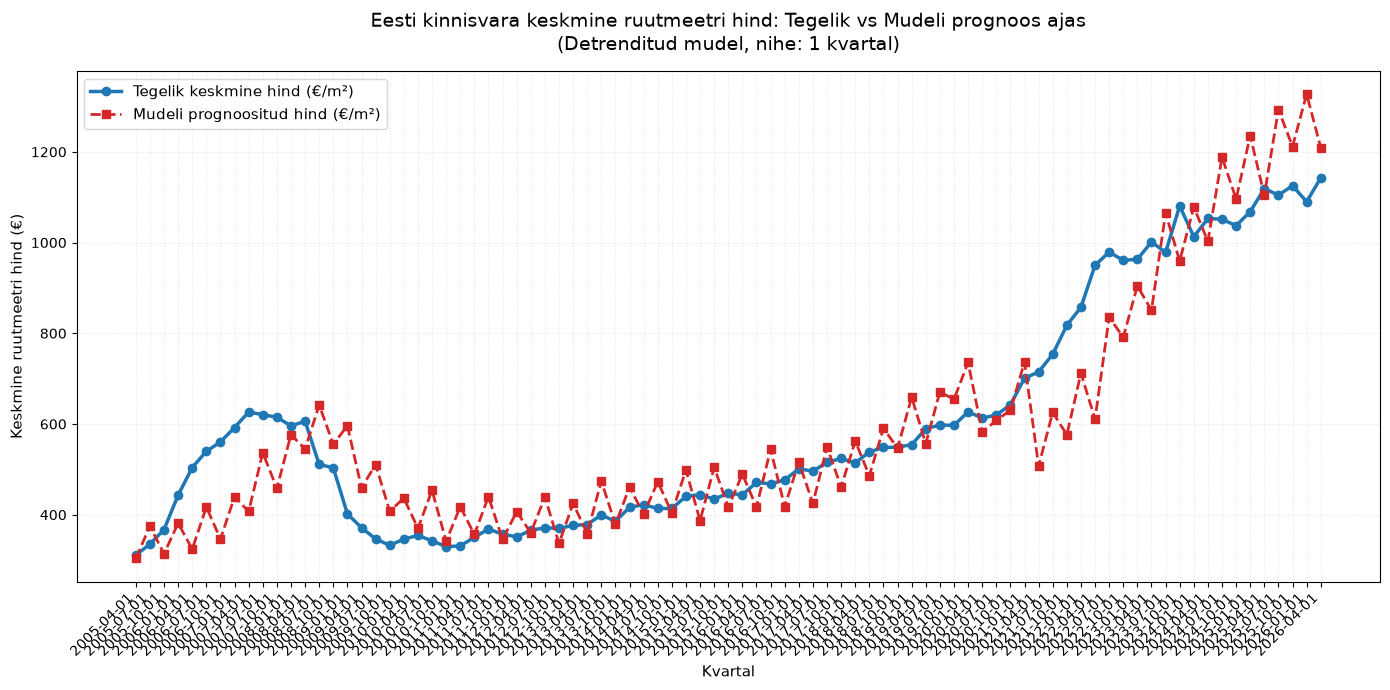

In [28]:
# 1. Kuna parimaks nihkeks oli 1, loome andmed otse joonise jaoks uuesti
parim_mudel = parim_loplis['Mudel']
nihe_parim = 1

df_joonis = df_dummies_all.copy()
df_joonis['palk_lag'] = df_joonis.groupby('fk_county_id')['keskmine_brutopalk'].shift(nihe_parim)
df_joonis['thi_lag'] = df_joonis.groupby('fk_county_id')['tarbijahinnaindeks'].shift(nihe_parim)
df_joonis['intress_lag'] = df_joonis.groupby('fk_county_id')['kodulaenu_intressimäär'].shift(nihe_parim)

# Eemaldame tühjad read
df_joonis = df_joonis.dropna(subset=['palk_lag', 'thi_lag', 'intress_lag', 'keskmine_ruutmeetri_hind'])

# 2. Arvutame mudeli prognoositud ruutmeetri hinnad
X_tunnused = df_joonis[parim_mudel.model.exog_names]
df_joonis['prognoositud_hind'] = parim_mudel.predict(X_tunnused)

# 3. Arvutame Eesti keskmise tegeliku ja prognoositud hinna iga kvartali kohta
df_ajatelg = df_joonis.groupby('fk_quarter_id').agg({
    'keskmine_ruutmeetri_hind': 'mean',
    'prognoositud_hind': 'mean'
}).sort_index()

# Muudame x-telje indeksid tekstiks, et graafik käitleks neid diskreetsete ajahetkedena
df_ajatelg.index = df_ajatelg.index.astype(str)

# 4. Joonistame aegrea (Line plot)
plt.figure(figsize=(14, 7))

# Tegelik hind sinise joonena
plt.plot(
    df_ajatelg.index, 
    df_ajatelg['keskmine_ruutmeetri_hind'], 
    marker='o', 
    color='#1f77b4', 
    linewidth=2.5, 
    label='Tegelik keskmine hind (€/m²)'
)

# Mudeli prognoos punase katkendjoonena
plt.plot(
    df_ajatelg.index, 
    df_ajatelg['prognoositud_hind'], 
    marker='s', 
    linestyle='--', 
    color='#d62728', 
    linewidth=2, 
    label='Mudeli prognoositud hind (€/m²)'
)

# Kujundus ja sildid
plt.title('Eesti kinnisvara keskmine ruutmeetri hind: Tegelik vs Mudeli prognoos ajas\n(Detrenditud mudel, nihe: 1 kvartal)', fontsize=14, pad=15)
plt.xlabel('Kvartal', fontsize=11)
plt.ylabel('Keskmine ruutmeetri hind (€)', fontsize=11)

plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, linestyle=':')
plt.legend(loc='upper left', fontsize=11, frameon=True)
plt.tight_layout()
plt.show()

### Salvestame tulemused CSV-sse välja, et saaksime neid kasutada app'is

In [29]:
# Salvestame sinu töötava, puhta andmestiku samasse kausta failina
df_analuys.to_csv("kinnisvara_koondandmed.csv", index=False)
print("Andmed edukalt salvestatud!")

Andmed edukalt salvestatud!
